In [9]:
print("Installing dependencies...")
%pip install langchain langgraph python-dotenv langchain-google-genai google-auth==2.49.0 -q
print("Dependencies installed. Please restart the  kernel")

Installing dependencies...
Note: you may need to restart the kernel to use updated packages.
Dependencies installed. Please restart the  kernel


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
from langchain.chat_models import init_chat_model
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

import os


In [4]:
print("Setting up memory saver for state graph persistence...")
from langgraph.checkpoint.memory import MemorySaver
print("Memory saver setup complete. Initializing memory...")
memory = MemorySaver()
print("Memory initialized for LLM to utilize successfully. Now, let's set up the state graph...")


Setting up memory saver for state graph persistence...
Memory saver setup complete. Initializing memory...
Memory initialized for LLM to utilize successfully. Now, let's set up the state graph...


In [5]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` reducer function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [22]:
@tool
def get_stock_price(symbol: str) -> float:
    '''Return the current price of a stock given the stock symbol
    :param symbol: stock symbol
    :return: current price of the stock
    '''
    return {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0,
        "RIL": 87.6
    }.get(symbol, 0.0)

tools = [get_stock_price]

print("Importing load_dotenv from dotenv...")
from dotenv import load_dotenv

# Explicitly load the sample.env file
print("Loading environment variables from sample.env...")
load_dotenv(dotenv_path="sample.env")

# Retrieve the key
print("Retrieving GEMINI_API_KEY from environment variables...")
api_key = os.getenv("GEMINI_API_KEY")
#print(f"GEMINI_API_KEY: {api_key}")

print("\033[1m" + "Initializing chat model with Google Gemini API..." + "\033[0m")
llm = init_chat_model("google_genai:gemini-3.6-flash", api_key=api_key)

print("\033[1m" + "Providing tools to the LLM..." + "\033[0m")
llm_with_tools = llm.bind_tools(tools)
print("Creating a state graph...", llm_with_tools, tools)

"""
state_graph = StateGraph[State](
    initial_state=State(messages=[]),
    llm=llm_with_tools,
    nodes=[
        ToolNode(name="get_stock_price", tools=tools, input_keys=["symbol"], output_key="price"),
    ],
    edges=[
        (START, "get_stock_price"),
        ("get_stock_price", END, tools_condition("price")),
    ]
)
"""

Importing load_dotenv from dotenv...
Loading environment variables from sample.env...
Retrieving GEMINI_API_KEY from environment variables...
Initializing chat model with Google Gemini API...
Providing tools to the LLM...
Creating a state graph... bound=ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18', 'langchain-google-genai': '4.3.7'}}, profile={'name': 'Gemini 3.6 Flash', 'release_date': '2026-07-21', 'last_updated': '2026-07-21', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True, 'reasoning_effort_levels': ['minimal', 'l

'\nstate_graph = StateGraph[State](\n    initial_state=State(messages=[]),\n    llm=llm_with_tools,\n    nodes=[\n        ToolNode(name="get_stock_price", tools=tools, input_keys=["symbol"], output_key="price"),\n    ],\n    edges=[\n        (START, "get_stock_price"),\n        ("get_stock_price", END, tools_condition("price")),\n    ]\n)\n'

Compiling the state graph with memory checkpointer, to bring persistence/temporality...
State graph compiled successfully with memory checkpointer.


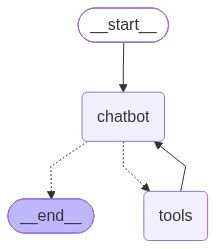

In [23]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node(chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")

print("\033[1m" + "Compiling the state graph with memory checkpointer, to bring persistence/temporality..." + "\033[0m")
graph = builder.compile(checkpointer=memory)
print("State graph compiled successfully with memory checkpointer.")
#graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [39]:
print("State graph is ready.\nYou can now invoke the graph with a message to get stock prices.\n")
print("===================================")
print("\033[1m" + "Your " + "\033[4;31m" + "agent's" + "\033[0m" + " indecisive brain (LLM=google_genai:gemini-3.6-flash/the trained weights) is now ready with \n\t" + "\033[4;31m" + "Tools\n\t" + "\033[4;31m" + "Memory: Threaded persistent memory\n" + "\033[0m" + "to process your request for\n\t" + "\033[4;31m" + "decision-making (deep reasoning, reflection and thinking)\n" + "\033[0m" + "Please provide a message to the chatbot." + "\033[0m")
print("===================================\n")

State graph is ready.
You can now invoke the graph with a message to get stock prices.

Your agent's indecisive brain (LLM=google_genai:gemini-3.6-flash/the trained weights) is now ready with 
	Tools
	Memory: Threaded persistent memory
to process your request for
	decision-making (deep reasoning, reflection and thinking)
Please provide a message to the chatbot.



In [ ]:
config1 = { 'configurable': { 'thread_id': '1'} }
print("Invoking the state graph with a sample message to calculate total cost of stocks...", llm, graph, config1, tools,)

msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config1)
print(state["messages"][-1].content)

In [9]:
config2 = { 'configurable': { 'thread_id': '2'} }

msg = "Tell me the current price of 5 AAPL stocks."

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config2)
print(state["messages"][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


[{'type': 'text', 'text': 'The current price of 1 share of AAPL stock is $100.40. \n\nTherefore, the total price for 5 AAPL stocks is **$502.00** (5 × $100.40).', 'extras': {'signature': 'EtoBCtcBARFNMg/eVZbWh2KOP5hTFM6+Sn1XmC4kPhbY5vwEXQpoiC8UAsAuMTyMjfE9THaL+X+9rpZJ6eDIjdScSfSuZYoMG/JcMylOUqsahjXK4s5BxgN6JhSC0vGyYeHfiIAC1yeOxHO6Ek43JEuiqAu5lVcsAtXLfsSdACodebrJk4fFgGxXt4Omtb5eHhId8nSDP3TK79H4hhXJv/iVzgvYLXq7xVJEGTryC4IHFsa7pHh3VCOBxnb1EzdA2KTzYHuuNR280yY+DxKp+IhGJFoHxZmd3yyjJDk='}}]


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [10]:
msg = "Using the current price tell me the total price of 10 RIL stocks and add it to previous total cost"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config1)
print(state["messages"][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


[{'type': 'text', 'text': 'The current price for **RIL** is **$87.60** per stock.\n\n**Cost Breakdown:**\n- **10 RIL stocks**: 10 × $87.60 = $876.00\n- **Previous total cost**: $6,004.50\n\n**New Total Cost:** $6,004.50 + $876.00 = **$6,880.50**', 'extras': {'signature': 'EscECsQEARFNMg/8EcdnmjtzKMFsPf/oRSf9vy3ytCsSFfk3BwZ6zMlj2PSodgElyomx0U5TF/ztUaF5FOYBzv76dKrd1DROO4UPU3n5zY/FffghX9FoIpJH6zRiqY1r0pfKKrHw5JS6sEISlvRFoebeEvIvEmbLJXcshHjhLZxnztMENnG0qgE7YWTGqqVmrqkxRcuarhdy9QK7gwzod8pwr73ljICAtj6VTrQyQE184ZCTNYcEuL/CV5xOdEXLaKTdpakmk/9RppJEyRn3h65DPICw6O5IZL51Q+zwVEZsjluV8lrek2GadmErls7umUZrStfPuX08raTDe20sWwdFU4a28G3XFGNu2xNY0smHKYpjHIVfalViFWIYVPtQNjVHN3MuZWvB1b9bAXMuvZZNAoH7a75LyYEr1+hroeCQU+XLkBCw3/z8Qji0QgLA5Ql/4Fq0nFomXoNPIPvotoYpubStu8ITsAjJBfMjAS1V59xbx/+r/jtSKpBOvlUXcSmVirBrPs9Tq7eZNwL3Xo6SEdUliLqAzugGNLdqab92z6IqVRuoUZK8rpZAL3vR0qPvcpn02XRayiy1/37BC7V02xZm3cHPTHMaozx26iXmID45nxVjcVYK5AlKRdm6VKIDEBhxTqfZzl2XkFJtqKThr/Z0hhOgplQYgU3s0qylt4nAo+VBumR/bE1EGwN+mY8dBjU63mniLY73CDk55Jr

In [11]:
msg = "Tell me the current price of 5 MSFT stocks and add it to previous total"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config2)
print(state["messages"][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


[{'type': 'text', 'text': 'The current price of 1 share of MSFT stock is $200.30, so 5 MSFT stocks cost **$1,001.50** (5 × $200.30).\n\nAdding this to the previous total of $502.00 (from 5 AAPL stocks):\n* **5 AAPL stocks:** $502.00\n* **5 MSFT stocks:** $1,001.50\n* **Combined Total:** **$1,503.50**', 'extras': {'signature': 'EsUCCsICARFNMg9VBiPnJTT+xy3aNbrXOGvFe/eFD8UPdKItBWKv7btX06dho4pqOZPr7qM9hoTQV968GAw8pmZSb37lcu+YMIVdUENKNFg+57kbN6GKxs4elEvUpHOXZBx0U61VdZ3yGsxYIEdRFfDyIG7fuenKwHTi0jSIt/sLXJM17TAJp5McfovAk0sMpU4tFy8R+sasRSBhbKsLxJT3YZZQRpenhk0cChxR+QcQSb1toePzk3+Z9cQAFVzT/fpj6ERtE0EetFTWx/DlO/oUTxiIIQJKgENWv7RlqsQSmy17GhWxfrT0NeZmDPWMjofCOUPTbguvbhOkV61sfchISF90SCnuwzXw4YuAmqHRF6GmK9HN/fGAe41e8AwSLvaJbI6uYSn3KgqjnKWXLeARJtzi5ujRb9L1FuHL28L2iVM80azYFQ=='}}]


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
